In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import *
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

## Загрузка данных

In [2]:
dataset_raw = pd.read_csv('data/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset_raw = dataset_raw.drop([0, 1, 2, 3, 504], axis=1)
dataset_raw.columns = list(range(500))
dataset_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [3]:
dataset_raw.shape

(23479, 500)

Датасет без преобразования выглядит так:

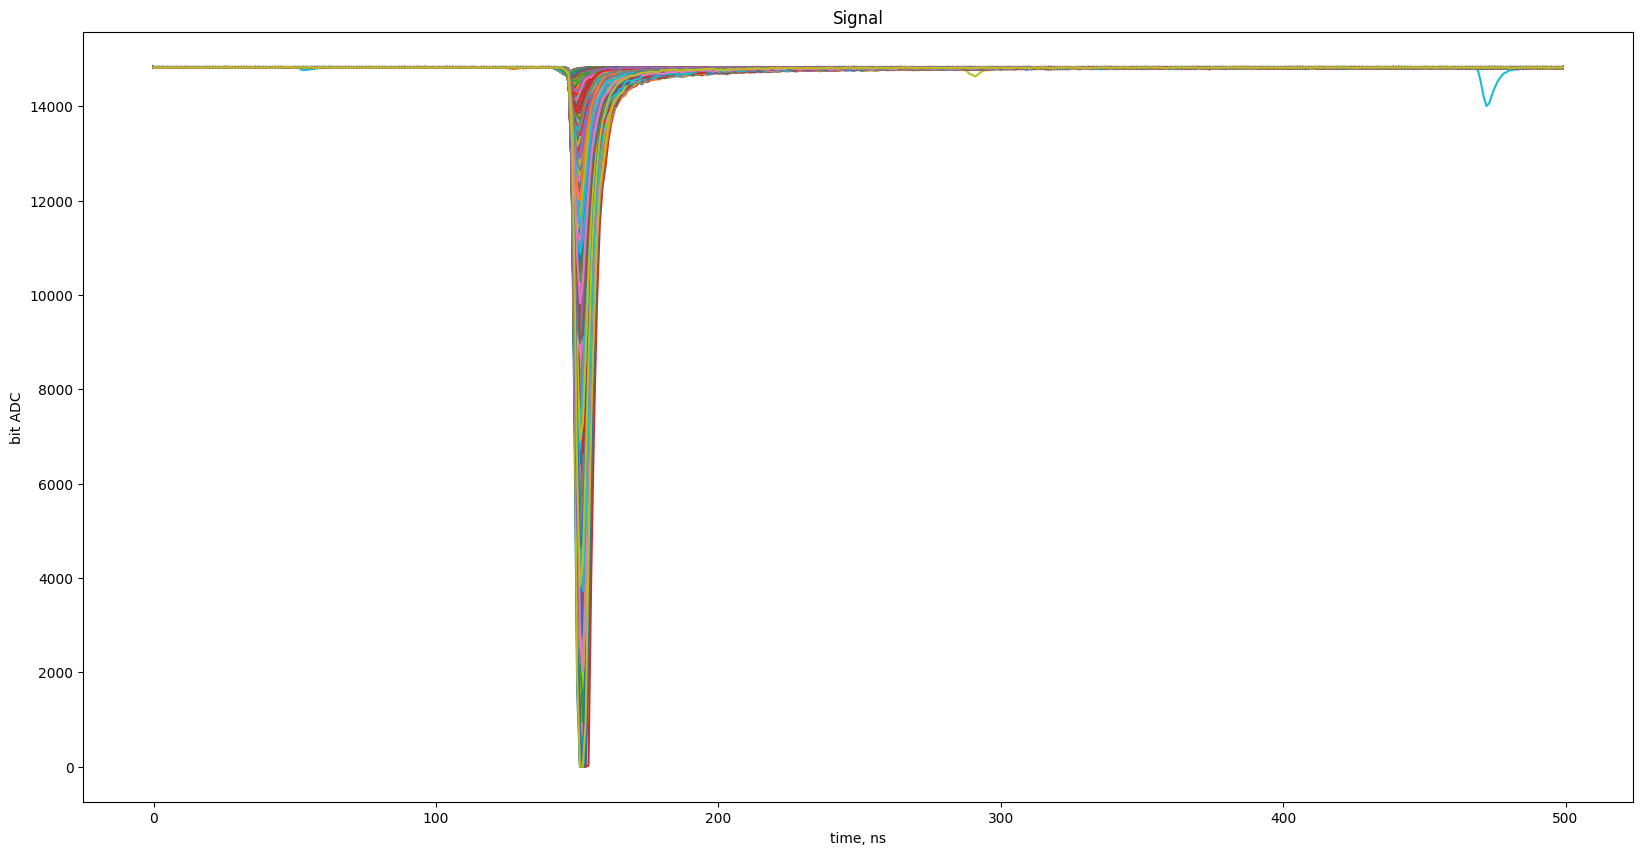

In [4]:
ax = dataset_raw.loc[:].T.plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")
plt.show()

## Подготовка данных

"Переворачиваю" импульсы

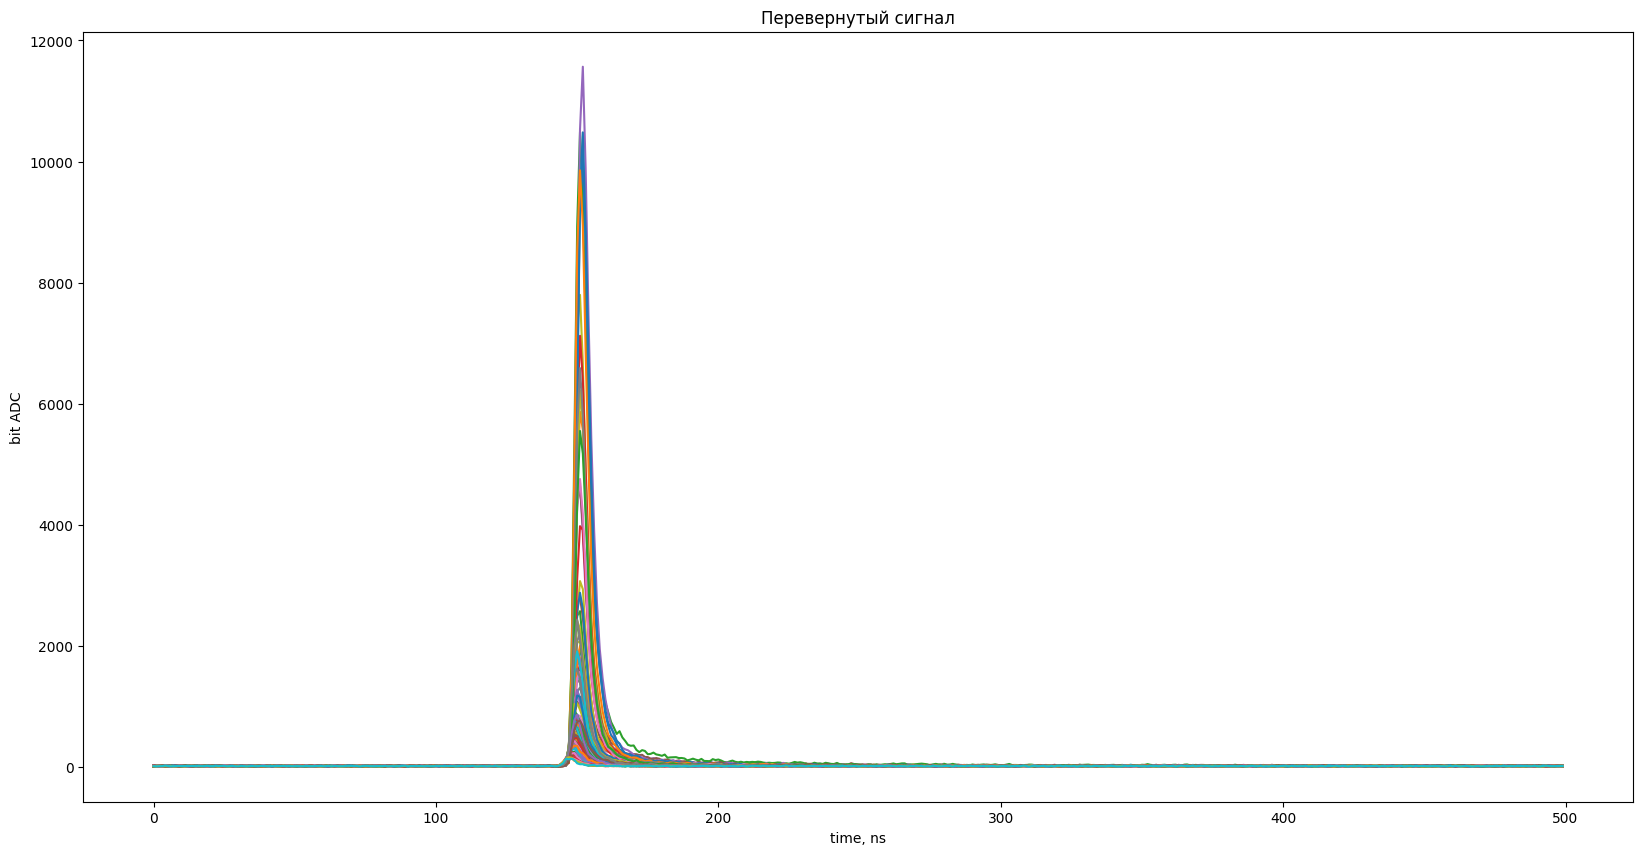

In [5]:
max_val = dataset_raw.max().max()
dataset_inverted = (dataset_raw * -1) + max_val
ax = dataset_inverted.loc[:].T[range(100)].plot(title='Перевернутый сигнал' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")
plt.show()

## Генерация признаков

Собираю информацию о шуме на участке без импульса -- первых 100 наблюдениях

In [6]:
noize = dataset_inverted.loc[:, :100].mean(axis=1)
noize_std = dataset_inverted.loc[:, :100].std(axis=1)

Получаю точную высоту пика

Высота самого маленького пика -- 118, самого большого -- 14838. Большая часть пиков не выше 1000. Высоты пика преобразовывать не буду

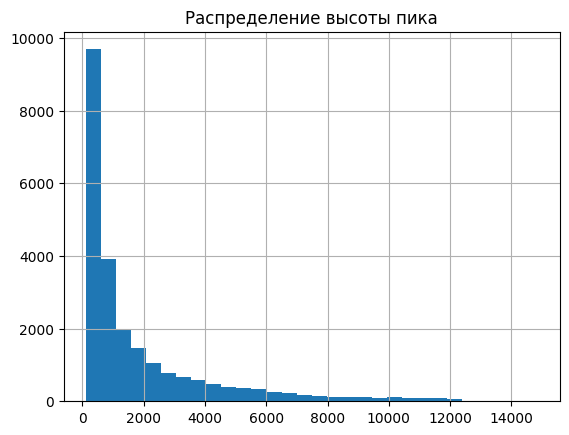

In [7]:
peak_height = dataset_inverted.max(axis=1)
plt.title("Распределение высоты пика")
peak_height.hist(bins=30)
plt.show()

In [8]:
peak_height.describe()

count    23479.000000
mean      1850.138209
std       2389.308983
min        119.000000
25%        323.000000
50%        828.000000
75%       2330.000000
max      14838.000000
dtype: float64

Нахожу точку, в которой пик находится. Как правило, это 150, но иногда немного раньше

In [9]:
peak_indices = []
for i in range(len(dataset_inverted)):
    row = dataset_inverted.loc[i, :]
    for j in range(152):
        if row[j] == peak_height[i]:
            peak_indices += [j]
            break
    else:
        peak_indices += [152]
            
peak_point = pd.Series(peak_indices)
peak_point.describe()

count    23479.000000
mean       149.614975
std          1.331810
min        145.000000
25%        149.000000
50%        150.000000
75%        151.000000
max        152.000000
dtype: float64

Выделяю конец пика. Считаю, что пик "заканчивается" тогда, когда снято наблюдение, не превышающее средний уровень шума до пика + стандартное отклонение

count    23479.000000
mean       203.388219
std         40.655330
min        154.000000
25%        172.000000
50%        190.000000
75%        225.000000
max        443.000000
dtype: float64


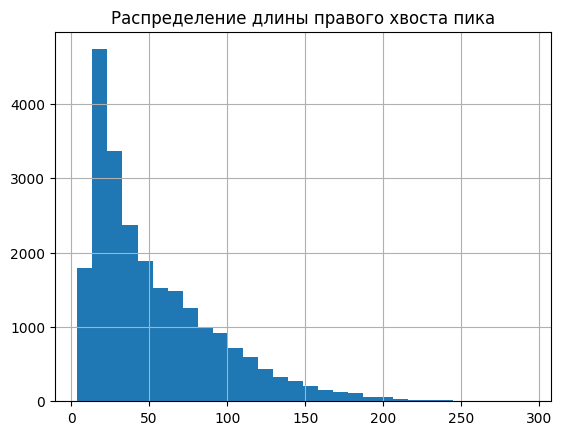

In [10]:
peak_end_indices = []
for i in range(len(dataset_inverted)):
    row = dataset_inverted.loc[i, :]
    for j in range(150, 500):
        if row[j] <= noize[i] + noize_std[i]:
            peak_end_indices += [j]
            break
    else:
        peak_end_indices += [499]
peak_end = pd.Series(peak_end_indices)
print(peak_end.describe())
plt.title("Распределение длины правого хвоста пика")
(peak_end - 150).hist(bins=30)
plt.show()

Выделяю индекс, с которого начинается левый хвост пика. Хвосты слева пика сильно короче хвостов справа. Не думаю, что это значение по отдельности сильно поможет при построении модели

count    23479.000000
mean       143.398569
std          1.051089
min        135.000000
25%        143.000000
50%        144.000000
75%        144.000000
max        146.000000
dtype: float64


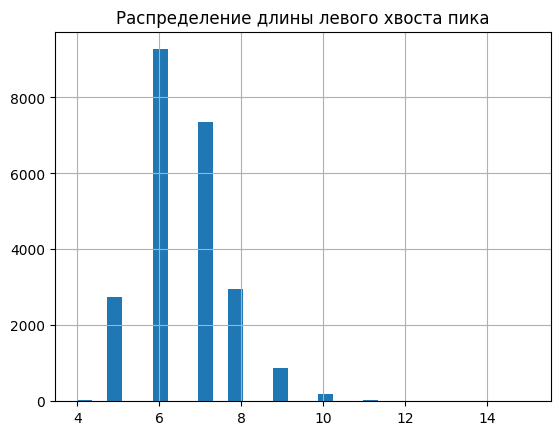

In [11]:
peak_start_indices = []
for i in range(len(dataset_inverted)):
    row = dataset_inverted.loc[i, :]
    for j in range(150, 0, -1):
        if row[j] <= noize[i] + noize_std[i]:
            peak_start_indices += [j]
            break
    else:
        peak_start_indices += [150]
peak_start = pd.Series(peak_start_indices)
print(peak_start.describe())
plt.title("Распределение длины левого хвоста пика")
(150 - peak_start).hist(bins=30)
plt.show()

Считаю ширину пика и соотношение ширины и высоты. Минимальная ширина пика -- 12 наблюдений

In [12]:
peak_width = peak_end - peak_start
height_to_width = peak_height / peak_width
print(f"Минимальная ширина пика: {peak_width.min()}")
peak_width.describe()

Минимальная ширина пика: 12


count    23479.000000
mean        59.989650
std         40.532788
min         12.000000
25%         29.000000
50%         46.000000
75%         81.000000
max        300.000000
dtype: float64

#### Расчет площадей, PSD и выбор длины для small

Считаю площадь для всего пика и для короткого периода

Так как минимальная ширина пика -- 12, то для ширины для короткого периода нужно было брать значение меньше 12

In [13]:
short_period_sum_11 = []
short_period_sum_7 = []
short_period_sum_3= []
short_period_sum_1 = []
long_period_sum = []
for i in range(len(dataset_inverted)):
    row = dataset_inverted.loc[i, :]
    short_period_sum_11 += [row[peak_start[i]:peak_indices[i] + 11].sum()]
    short_period_sum_7 += [row[peak_start[i]:peak_indices[i] + 7].sum()]
    short_period_sum_3 += [row[peak_start[i]:peak_indices[i] + 3].sum()]
    short_period_sum_1 += [row[peak_start[i]:peak_indices[i] + 1].sum()]
    
    long_period_sum += [row[peak_start[i]:peak_end_indices[i]].sum()]
long_period_area = pd.Series(long_period_sum)
short_period_area_11 = pd.Series(short_period_sum_11)
short_period_area_7 = pd.Series(short_period_sum_7)
short_period_area_3 = pd.Series(short_period_sum_3)
short_period_area_1 = pd.Series(short_period_sum_1)

In [14]:
psd_11 = (long_period_area - short_period_area_11) / long_period_area
psd_7 = (long_period_area - short_period_area_7) / long_period_area
psd_3 = (long_period_area - short_period_area_3) / long_period_area
psd_1 = (long_period_area - short_period_area_1) / long_period_area

При выборе ширины для короткого периода я выбирала между 1, 3, 7 и 11. Разделения при ширинах 11 и 7 примерно одинаковы и лучше, чем для 1 и 3, взяла ширину 11 для короткого периода для PSD

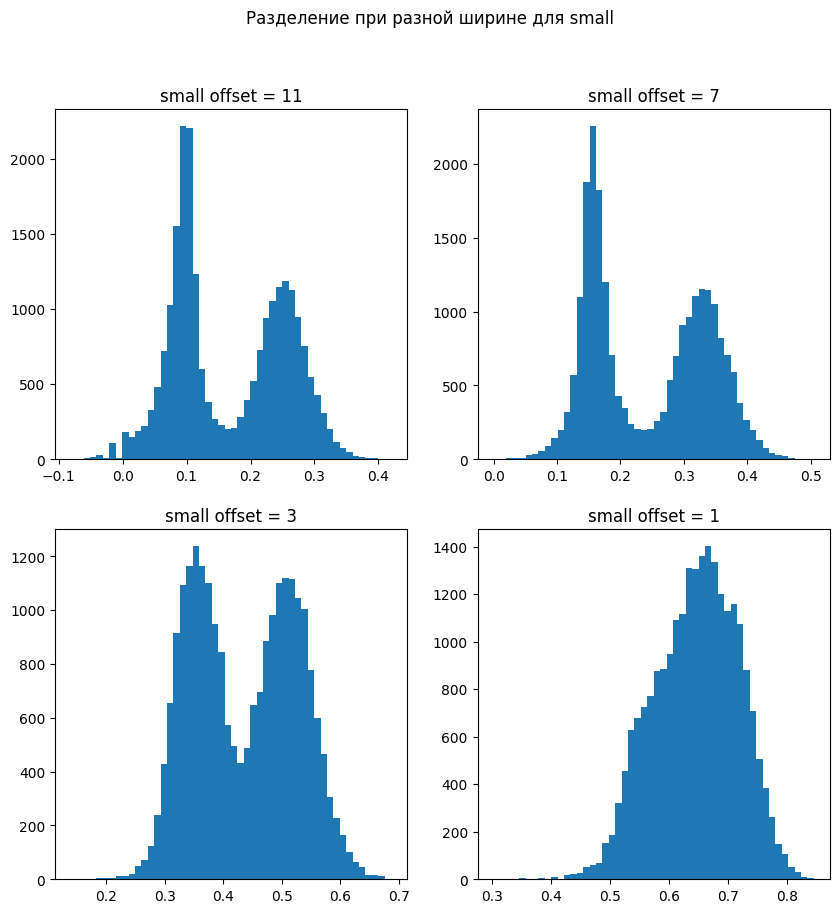

In [15]:
fig, axs = plt.subplots(2, 2)
fig.set_size_inches(10, 10)
axs[0, 0].set_title("small offset = 11")
axs[0, 1].set_title("small offset = 7")
axs[1, 0].set_title("small offset = 3")
axs[1, 1].set_title("small offset = 1")
axs[0, 0].hist(psd_11, bins=50)
axs[0, 1].hist(psd_7, bins=50)
axs[1, 0].hist(psd_3, bins=50)
axs[1, 1].hist(psd_1, bins=50)
fig.suptitle("Разделение при разной ширине для small")
plt.show()

#### Формирование датасета

В финальный датасет не беру изначальный набор данных, а только расчетные признаки:
- PSD
- Общая площадь пика (она же в нашем случае long)
- Ширина пика
- Высота пика
- Отношение высоты пика к его ширине

In [16]:
data = pd.DataFrame([psd_11, long_period_area, peak_width, peak_height, height_to_width]).T
data.columns = ["pds", "total_area", "peak_width", "peak_height", "height_to_width"]

Визуализация признаков. Уже на основе нее можно понять, как примерно будет выглядеть деление на 3 кластера

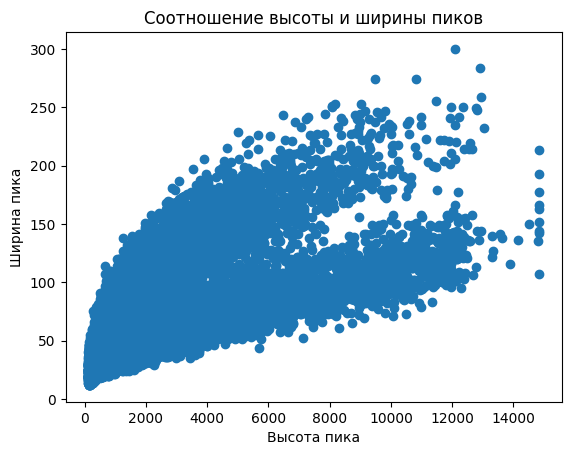

In [17]:
plt.title("Соотношение высоты и ширины пиков")
plt.scatter(data["peak_height"], data["peak_width"])
plt.xlabel("Высота пика")
plt.ylabel("Ширина пика")
plt.show()

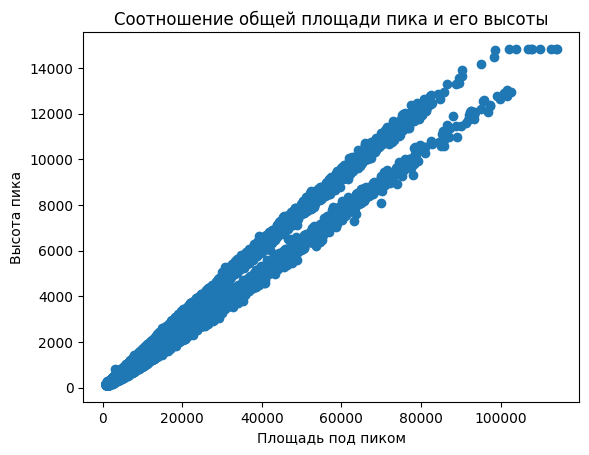

In [18]:
plt.title("Соотношение общей площади пика и его высоты")
plt.scatter(data["total_area"], data["peak_height"])
plt.xlabel("Площадь под пиком")
plt.ylabel("Высота пика")
plt.show()

### Обучение модели

Что я ожидаю:

Так как кластера нестандартной формы, то KMeans практически гарантированно не справится с кластеризацией. Я рассчитываю на 2 основных метода для кластеризации: Gaussian Mixture и DBSCAN. Теоретически с нашей формой кластеров могла бы справиться спектральная кластеризация, но на практике SpectralClustering из scikit-learn очень медленно работает даже на нашем небольшом датасете, поэтому я его и не рассматривала

Когда я рассматривала, как можно подготовить данные к кластеризации (нужно как минимум масштабирование, так как высота пиков больше других показателей по масштабам), я поняла, что выделение компонент в нашем случае тоже дает довольно интересное разделение данных. Решила оставить это как способ кластеризации

#### Подход 1: StandardScaler + PCA + ручное разделение кластеров

Применила StandardScaler, выделила 2 компоненты с помощью метода главных компонент. На визуализации с ними видно, как кластера можно попробовать разделить прямыми

Визуально результат разделения выглядит очень хорошо. Мне также нравится, что количество элементов в кластерах накладывается на теорию: есть два больших примерно одинаковых кластера и небольшой кластер с выбросами

In [19]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pca_2 = PCA(2)
data_pca_2_np = pca_2.fit_transform(data_scaled)
data_pca_2 = pd.DataFrame(data_pca_2_np, columns=["PCA1", "PCA2"])

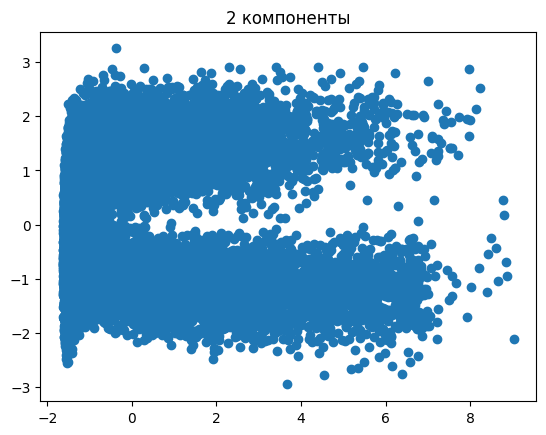

In [20]:
plt.title("2 компоненты")
plt.scatter(data_pca_2["PCA1"], data_pca_2["PCA2"])
plt.show()

In [21]:
data_pca_2["label_1"] = (data_pca_2["PCA2"] < 0).astype("int")
data_pca_2["label_2"] = ((data_pca_2["PCA2"] < -2.3) & (data_pca_2["PCA1"] < 0)).astype("int")
data_pca_2["label"] = data_pca_2["label_1"] + data_pca_2["label_2"]

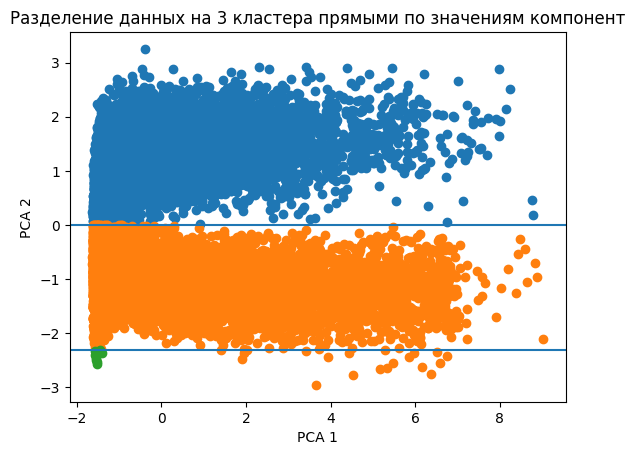

In [22]:
plt.title("Разделение данных на 3 кластера прямыми по значениям компонент")
for i in range(3):
    cluster = data_pca_2[data_pca_2["label"] == i]
    plt.scatter(cluster["PCA1"], cluster["PCA2"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.axline((0, 0), (9, 0))
plt.axline((1, -2.3), (0, -2.3))
plt.show()

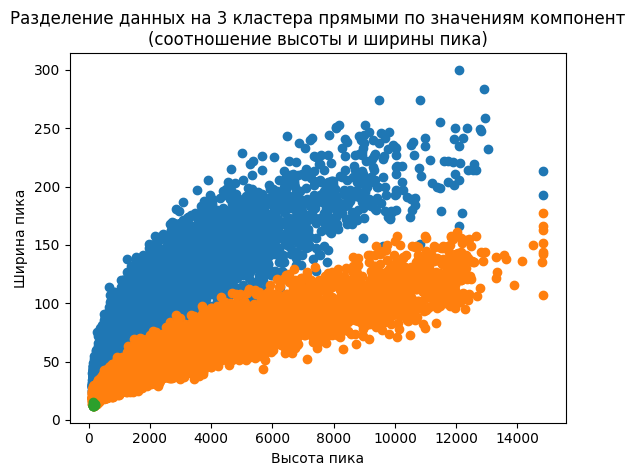

In [23]:
plt.title("Разделение данных на 3 кластера прямыми по значениям компонент\n(соотношение высоты и ширины пика)")
for i in range(3):
    cluster = data[data_pca_2["label"] == i]
    plt.scatter(cluster["peak_height"], cluster["peak_width"])
plt.xlabel("Высота пика")
plt.ylabel("Ширина пика")
plt.show()

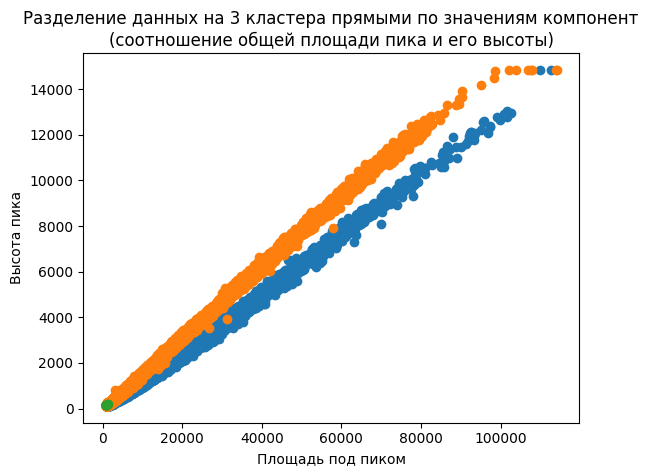

In [24]:
plt.title("Разделение данных на 3 кластера прямыми по значениям компонент\n(cоотношение общей площади пика и его высоты)")
for i in range(3):
    cluster = data[data_pca_2["label"] == i]
    plt.scatter(cluster["total_area"], cluster["peak_height"])
plt.xlabel("Площадь под пиком")
plt.ylabel("Высота пика")
plt.show()

In [25]:
print("Количество элементов в кластерах")
data_pca_2.groupby("label")["label"].count()

Количество элементов в кластерах


label
0    10990
1    12478
2       11
Name: label, dtype: int64

In [26]:
silhouette_score(data, data_pca_2["label"])

-0.4363122227407514

#### Подход 2: StandardScaler + PCA + GaussianMixture

Применяю GaussianMixture на преобразованных данных с выделенными главными компонентами

GaussianMixture со стандартным параметром вида матрицы ковариации справляется с задачей плохо. Для улучшения разделения помогает использование параметра covariance_type='tied', но разделение все равно не такое четкое, как при использовании только метода главных компонент

Получается достаточно серьезный перекос в сторону кластера с выбросами

In [27]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pca = PCA()
data_pca_np = pca.fit_transform(data_scaled)
data_pca = pd.DataFrame(data_pca_np)

data_for_gaussian_mixture = data_pca.copy()
gaussian_mixture = GaussianMixture(n_components=3, random_state=42)
data_for_gaussian_mixture["label"] = gaussian_mixture.fit_predict(data_for_gaussian_mixture)

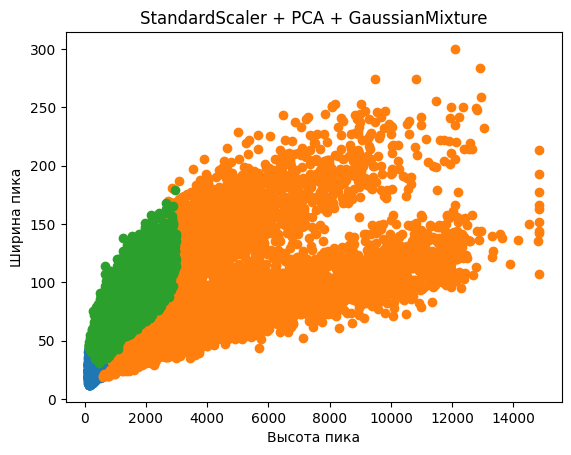

In [28]:
plt.title("StandardScaler + PCA + GaussianMixture")
for i in range(3):
    cluster = data[data_for_gaussian_mixture["label"] == i]
    plt.scatter(cluster["peak_height"], cluster["peak_width"])
plt.xlabel("Высота пика")
plt.ylabel("Ширина пика")
plt.show()

In [29]:
data_for_gaussian_mixture_tied = data_pca.copy()
gaussian_mixture = GaussianMixture(n_components=3, random_state=42, covariance_type="tied")
data_for_gaussian_mixture_tied["label"] = gaussian_mixture.fit_predict(data_for_gaussian_mixture_tied)

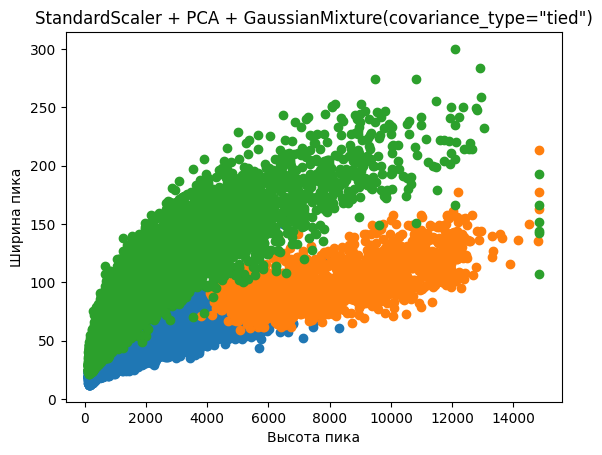

In [30]:
plt.title("StandardScaler + PCA + GaussianMixture(covariance_type=\"tied\")")
for i in range(3):
    cluster = data[data_for_gaussian_mixture_tied["label"] == i]
    plt.scatter(cluster["peak_height"], cluster["peak_width"])
plt.xlabel("Высота пика")
plt.ylabel("Ширина пика")
plt.show()

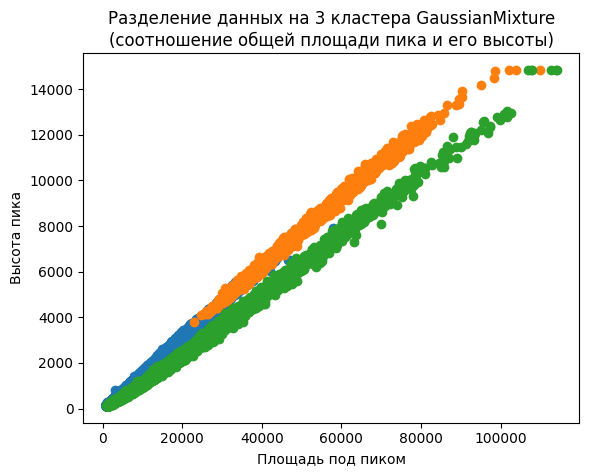

In [31]:
plt.title("Разделение данных на 3 кластера GaussianMixture\n(cоотношение общей площади пика и его высоты)")
for i in range(3):
    cluster = data[data_for_gaussian_mixture_tied["label"] == i]
    plt.scatter(cluster["total_area"], cluster["peak_height"])
plt.xlabel("Площадь под пиком")
plt.ylabel("Высота пика")
plt.show()

In [32]:
silhouette_score(data, data_for_gaussian_mixture_tied["label"])

0.03472817059892676

#### Подход 3: StandardScaler + PCA + KMeans
Применяю KMeans на преобразованных данных с выделенными главными компонентами

На кластерах нестандартной формы и разной плотности KMeans справляется ожидаемо плохо

In [33]:
data_for_kmeans = data_pca.copy()
kmeans = KMeans(n_clusters=3, random_state=42)
data_for_kmeans["label"] = kmeans.fit_predict(data_for_kmeans)

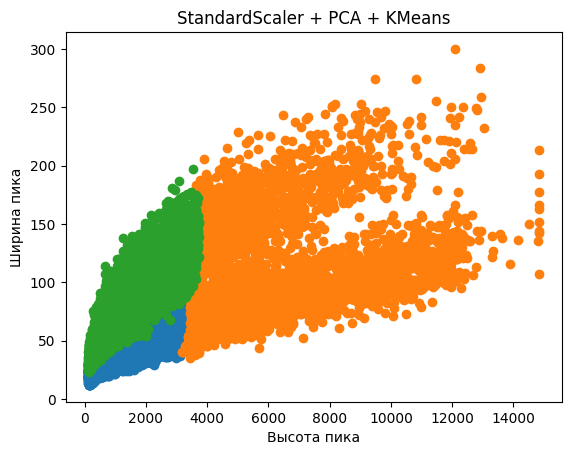

In [34]:
plt.title("StandardScaler + PCA + KMeans")
for i in range(3):
    cluster = data[data_for_kmeans["label"] == i]
    plt.scatter(cluster["peak_height"], cluster["peak_width"])
plt.xlabel("Высота пика")
plt.ylabel("Ширина пика")
plt.show()

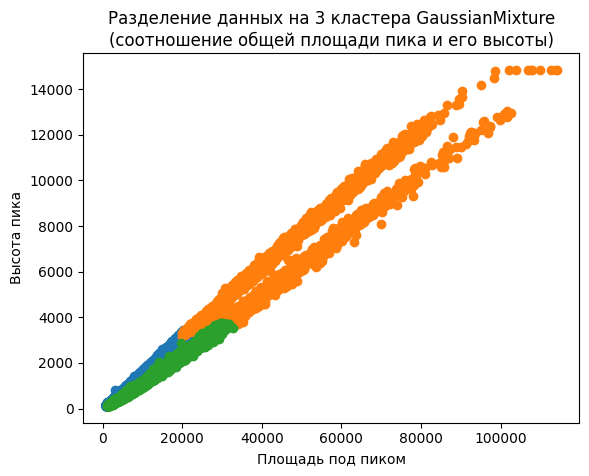

In [35]:
plt.title("Разделение данных на 3 кластера GaussianMixture\n(cоотношение общей площади пика и его высоты)")
for i in range(3):
    cluster = data[data_for_kmeans["label"] == i]
    plt.scatter(cluster["total_area"], cluster["peak_height"])
plt.xlabel("Площадь под пиком")
plt.ylabel("Высота пика")
plt.show()

#### Подход 4: StandardScaler + PCA + DBSCAN

Так как по условию задачи известно, что кластера 3, то для DBSCAN нужно подбирать epsilon, исходя из этого факта

При первом исследовании датасета я столкнулась с тем, что DBSCAN формировал огромный кластер и несколько кластеров из менее 10 наблюдений. Так как я заранее знаю, что жду два больших и один маленький кластер, то задаю большой минимальный размер кластера и считаю, что в маленький попадут значения в кластер выбросов 

Сначала прохожусь по eps = 0.1, 0.2, ..., 1

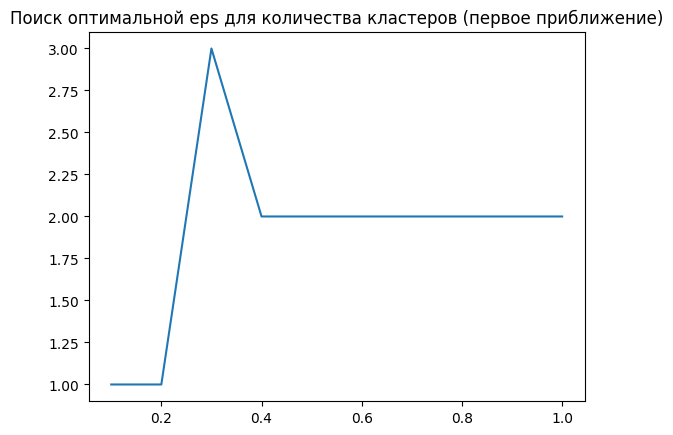

In [36]:
data_for_dbscan = data_pca.copy()
num_clusters = []
eps = [i * 0.1 for i in range(1, 11)]
for i in eps:
    dbscan_test = DBSCAN(eps=i, min_samples=1000, n_jobs=-1)
    num_clusters += [pd.Series(dbscan_test.fit_predict(data_for_dbscan)).nunique()]
plt.title("Поиск оптимальной eps для количества кластеров (первое приближение)")
plt.plot(eps, num_clusters)
plt.show()

Оптимальное значение где-то между 0.2 и 0.4

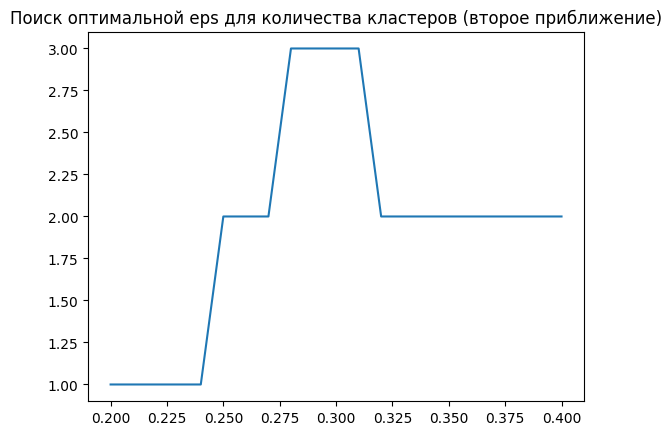

In [37]:
data_for_dbscan = data_pca.copy()
num_clusters_2 = []
eps_2 = [0.2 + i * 0.01 for i in range(0, 21)]
for i in eps_2:
    dbscan_test = DBSCAN(eps=i, min_samples=1000, n_jobs=-1)
    num_clusters_2 += [pd.Series(dbscan_test.fit_predict(data_for_dbscan)).nunique()]
plt.title("Поиск оптимальной eps для количества кластеров (второе приближение)")
plt.plot(eps_2, num_clusters_2)
plt.show()

Возьму eps=0.3

In [38]:
dbscan = DBSCAN(eps=0.3, min_samples=1000, n_jobs=-1)
data_for_dbscan["label"] = dbscan.fit_predict(data_for_dbscan)

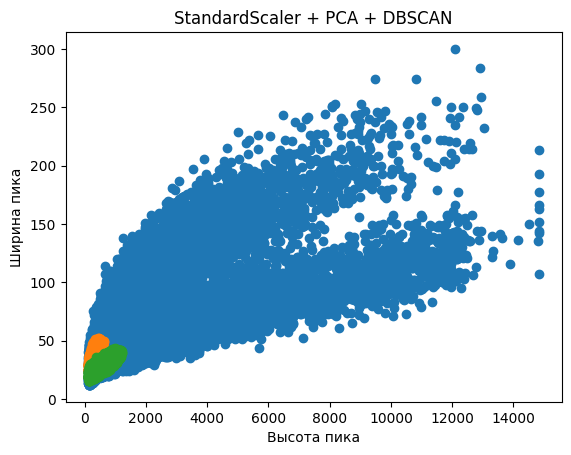

In [39]:
plt.title("StandardScaler + PCA + DBSCAN")
for i in range(-1, 3):
    cluster = data[data_for_dbscan["label"] == i]
    plt.scatter(cluster["peak_height"], cluster["peak_width"])
plt.xlabel("Высота пика")
plt.ylabel("Ширина пика")
plt.show()

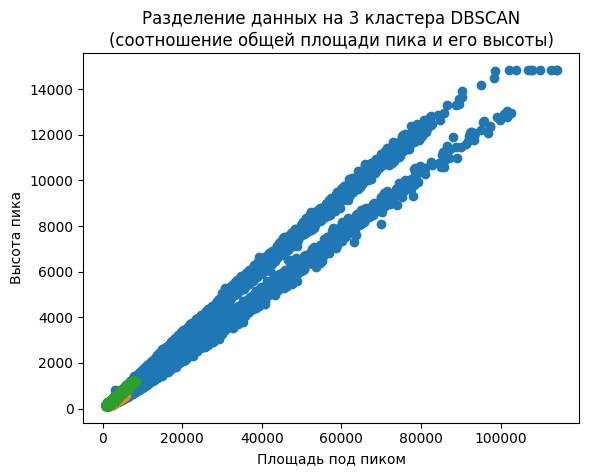

In [40]:
plt.title("Разделение данных на 3 кластера DBSCAN\n(cоотношение общей площади пика и его высоты)")
for i in range(-1, 3):
    cluster = data[data_for_dbscan["label"] == i]
    plt.scatter(cluster["total_area"], cluster["peak_height"])
plt.xlabel("Площадь под пиком")
plt.ylabel("Высота пика")
plt.show()

Разделение все равно получилось плохим, DBSCAN создал кластера минимального размера и отнес большую часть наблюдений в выбросы

In [41]:
data_for_dbscan.groupby("label")["label"].count()

label
-1    14627
 0     3001
 1     5851
Name: label, dtype: int64

### Формирование результата

Визуально лучший результат показало использование метода главных компонент и разделение кластеров прямыми. При таком способе кластер с выбросами получается небольшим, а два главных кластера близки по размеру

In [42]:
clustered_data = data_pca_2

In [43]:
# df0 = pd.DataFrame(pd.Series(kmeans.labels_), columns=["label"])
clustered_data['cluster'] = -1
i = 0
for lbl in pd.Series(clustered_data["label"]).unique():
    clustered_data.loc[clustered_data['label'] == lbl, 'cluster'] = i
    i += 1
clustered_data.index.name = 'index'
clustered_data["cluster"].to_csv(f"pca_visual.csv")